# EDA 12: PRISM Drug Response

## Purpose

PRISM exposes many cancer cell lines to thousands of compounds. A negative log-fold-change generally means fewer cells remained after treatment, suggesting sensitivity. This can support a result such as "models dependent on gene B also respond to a drug targeting B," but drug response does not prove a gene pair and this public PRISM release is not matched to DepMap 24Q4.

## Column dictionary

| Table / column | Meaning | Project use |
| --- | --- | --- |
| Response `Unnamed: 0` | DepMap model ID for one response row. | Crosswalk to `model_id`; one row per screened model. |
| Response treatment columns | Replicate-collapsed log-fold-change after treatment. | Treatment sensitivity context; lower values generally mean stronger growth reduction. |
| `column_name` | Exact treatment-column key. | Safe response-to-treatment metadata join. |
| `broad_id`, `name`, `dose`, `screen_id` | Compound identity, name, dose, and screen. | Treatment provenance. |
| `moa`, `target` | Reported mechanism of action and gene target(s). | Biological/drug-target explanation, not guaranteed proof of specificity. |
| `disease.area`, `indication`, `phase` | Development and clinical context. | Supporting interpretation. |
| Cell-line `depmap_id`, `model_id`, `model_id_match_status`, `ccle_name` | PRISM-to-DepMap crosswalk and match evidence. | Makes unmatched models visible. |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown,display
pd.set_option('display.max_columns',100); pd.set_option('display.max_rows',100); sns.set_theme(style='whitegrid')
def find_root(s):
    for c in (s,*s.parents):
        if (c/'data'/'depmap_24Q4'/'architecture'/'model_master.csv').exists(): return c
    raise FileNotFoundError('Run inside az-team25.')
ROOT=find_root(Path.cwd().resolve()); DATA=ROOT/'data'; CORE=DATA/'depmap_24Q4'; EXT=DATA/'external'
master=pd.read_csv(CORE/'architecture'/'model_master.csv',low_memory=False)

P=EXT/'prism_repurposing'; response=pd.read_csv(P/'raw'/'primary-screen-replicate-collapsed-logfold-change.csv',low_memory=False); treatments=pd.read_csv(P/'derived'/'prism_treatment_catalog.csv',low_memory=False); catalog=pd.read_csv(P/'derived'/'prism_cell_line_catalog.csv',low_memory=False)
response=response.rename(columns={response.columns[0]:'model_id'}); treatment_cols=response.columns[1:].tolist()
print(response.shape,treatments.shape,catalog.shape); display(treatments.head())

(578, 4687) (4686, 11) (588, 6)


,column_name,broad_id,name,dose,screen_id,moa,target,disease.area,indication,smiles,phase
0,BRD-A00055058-001-01-0::2.325889319::MTS004,BRD-A00055058-001-01-0,RS-0481,2.325889,MTS004,immunostimulant,NaN,NaN,NaN,CC(NC(=O)C1CSCN1C(=O)c1ccccc1)c1ccccc1,Phase 2
1,BRD-A00842753-001-01-9::2.5::MTS004,BRD-A00842753-001-01-9,oleuropein,2.500000,MTS004,estrogen receptor agonist,GPER1,NaN,NaN,COC(=O)C1=COC(OC2OC(CO)C(O)C(O)C2O)\C(=C/C)C1C...,Phase 2
2,BRD-A02232681-001-01-8::2.5::MTS004,BRD-A02232681-001-01-8,isoleucine,2.500000,MTS004,NaN,"ACADSB, BCAT1, BCAT2, IARS, IARS2",NaN,NaN,CCC(C)C(N)C(O)=O,Launched
3,BRD-A04447196-001-01-8::2.5::MTS004,BRD-A04447196-001-01-8,gepefrine,2.500000,MTS004,adrenergic receptor agonist,NaN,cardiology,hypotension,CC(N)Cc1cccc(O)c1,Launched
4,BRD-A04971881-003-01-3::2.65294603::MTS004,BRD-A04971881-003-01-3,cloranolol,2.652946,MTS004,adrenergic receptor antagonist,"ADRB1, ADRB2, ADRB3",NaN,NaN,CC(C)(C)NCC(O)COc1cc(Cl)ccc1Cl,Launched


## 1. Identity, treatment joins, and coverage

We verify model IDs and exact treatment-column matches before examining values.

In [2]:
ids=set(response.model_id); master_ids=set(master.model_id); unmatched_response_ids=sorted(ids-master_ids)
audit=pd.DataFrame([{'response_models':response.model_id.nunique(),'duplicate_response_models':int(response.model_id.duplicated().sum()),'matched_response_models':len(ids & master_ids),'response_models_not_in_master':len(unmatched_response_ids),'treatment_columns':len(treatment_cols),'catalog_rows':len(treatments),'unmatched_treatment_columns':len(set(treatment_cols)-set(treatments.column_name)),'catalog_models_directly_matched':catalog.model_id.notna().sum()}]); display(audit)
display(pd.DataFrame({'unmatched_response_id':unmatched_response_ids,'interpretation':'FAILED_STR source label; retained in raw PRISM but excluded from 24Q4-linked analyses'}))
assert response.model_id.is_unique and not(set(treatment_cols)-set(treatments.column_name))
matched_response=response.loc[response.model_id.isin(master_ids)].copy()
context=matched_response[['model_id']].merge(master[['model_id','oncotree_lineage']],on='model_id',how='left',validate='one_to_one'); display(context.oncotree_lineage.value_counts().to_frame('PRISM models'))

,response_models,duplicate_response_models,matched_response_models,response_models_not_in_master,treatment_columns,catalog_rows,unmatched_treatment_columns,catalog_models_directly_matched
0,578,0,568,10,4686,4686,0,568


,unmatched_response_id,interpretation
0,ACH-000010_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
1,ACH-000028_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
2,ACH-000409_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
3,ACH-000460_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
4,ACH-000511_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
5,ACH-000539_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
6,ACH-000807_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
7,ACH-000925_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
8,ACH-000992_FAILED_STR,FAILED_STR source label; retained in raw PRISM...
9,ACH-001078_FAILED_STR,FAILED_STR source label; retained in raw PRISM...


,PRISM models
oncotree_lineage,
Lung,100
Esophagus/Stomach,45
Skin,43
CNS/Brain,42
Ovary/Fallopian Tube,38
Pancreas,37
Bowel,35
Head and Neck,28
Breast,26


### What this means for the project

Only screened, matched models belong in a drug-response denominator. A cell line missing from PRISM is not drug-resistant; it was not measured in this matrix. Ten response rows have `_FAILED_STR` source labels and cannot be mapped to the 24Q4 identity spine, so they remain visible in the audit but are excluded from model-linked calculations.

## 2. Response distributions and variable treatments

We inspect missingness, broad response ranges, and treatments that separate models most strongly. Variation is useful for exploration but is not a validated drug threshold.

,count,mean,std,min,25%,50%,75%,max
mean,4686.0,-0.223338,0.684446,-4.434968,-0.210575,-0.037748,0.084856,0.537662
median,4686.0,-0.205710,0.684773,-4.448750,-0.185759,-0.020496,0.098112,0.542375
sd,4686.0,0.490513,0.259986,0.260965,0.353839,0.390731,0.480570,1.697485
missing_pct,4686.0,2.818415,2.080929,0.519031,1.211073,2.249135,4.844291,19.723183
negative_pct,4686.0,52.881070,20.555214,5.190311,37.370242,50.519031,66.262976,99.307958


,name,target,moa,dose,sd,negative_pct
1546,simvastatin,"HMGCR, ITGB2",HMGCR inhibitor,2.42,1.697485,62.975779
3017,fluvastatin,HMGCR,HMGCR inhibitor,2.63,1.675492,81.833910
2152,KW-2478,NaN,HSP inhibitor,2.50,1.628097,85.467128
4016,10-deacetylbaccatin,NaN,antitumor agent,2.43,1.624729,65.397924
3340,pitavastatin,HMGCR,HMGCR inhibitor,2.50,1.606578,65.570934
822,RITA,MDM2,MDM inhibitor,2.40,1.596541,72.837370
4006,Y-320,IL17A,interleukin inhibitor,2.50,1.582022,89.100346
1230,AR-42,HDAC1,HDAC inhibitor,2.50,1.573009,95.847751
2749,NMS-E973,NaN,HSP inhibitor,2.50,1.570920,90.657439
1049,tetrandrine,SLC6A3,calcium channel blocker,2.50,1.565503,65.570934


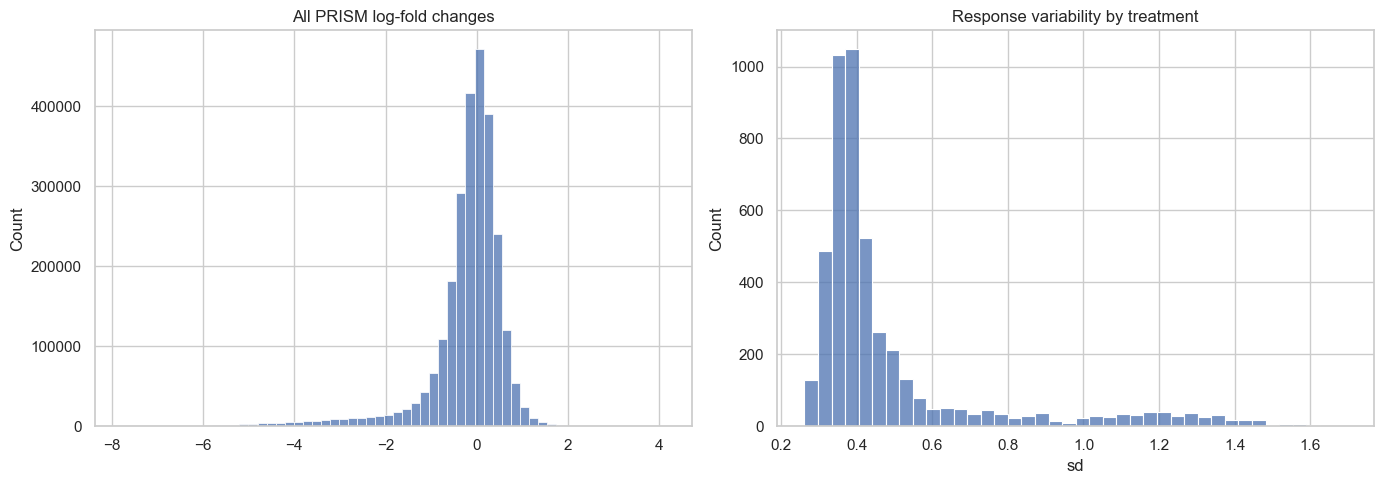

In [3]:
v=response[treatment_cols]; ts=pd.DataFrame({'column_name':treatment_cols,'mean':v.mean().values,'median':v.median().values,'sd':v.std().values,'missing_pct':100*v.isna().mean().values,'negative_pct':100*v.lt(0).mean().values}).merge(treatments,on='column_name',how='left',validate='one_to_one')
display(ts[['mean','median','sd','missing_pct','negative_pct']].describe().T); display(ts.nlargest(25,'sd')[['name','target','moa','dose','sd','negative_pct']])
fig,axes=plt.subplots(1,2,figsize=(14,5)); sns.histplot(v.to_numpy().ravel(),bins=60,ax=axes[0]); axes[0].set_title('All PRISM log-fold changes'); sns.histplot(ts.sd,bins=40,ax=axes[1]); axes[1].set_title('Response variability by treatment'); plt.tight_layout(); plt.show()

### What this means for the project

A very negative value says treatment reduced growth in that experiment. It does not prove the reported target caused the response, because compounds can affect several proteins and target annotations can be incomplete.

## 3. Target metadata and decisions

We measure target coverage and inspect example gene-targeted treatments without adding PRISM to the core score.

In [4]:
meta=pd.DataFrame({'field':['name','moa','target','phase'],'available': [treatments[c].notna().sum() for c in ['name','moa','target','phase']],'total':len(treatments)}); meta['available_pct']=100*meta.available/meta.total; display(meta)
for gene in ['EGFR','ALK','BRAF','PARP1']:
    subset=ts.loc[ts.target.fillna('').str.contains(gene,case=False,regex=False),['name','target','moa','dose','median','sd','negative_pct']]
    display(Markdown(f'#### Treatments whose target text contains `{gene}`')); display(subset.head(20))

,field,available,total,available_pct
0,name,4685,4686,99.978660
1,moa,4325,4686,92.296201
2,target,3464,4686,73.922322
3,phase,4685,4686,99.978660


#### Treatments whose target text contains `EGFR`

,name,target,moa,dose,median,sd,negative_pct
1015,BMS-599626,"EGFR, ERBB2, ERBB4","EGFR inhibitor, protein tyrosine kinase inhibitor",2.5,-0.131884,0.626345,59.688581
1029,WHI-P154,"EGFR, JAK1, JAK2, JAK3",JAK inhibitor,2.5,0.014048,0.483136,48.615917
1078,pelitinib,EGFR,EGFR inhibitor,2.5,-0.561523,0.933888,73.875433
1227,CGP-52411,EGFR,EGFR inhibitor,2.5,0.056638,0.421187,41.003460
1373,tyrphostin-AG-835,EGFR,protein tyrosine kinase inhibitor,2.5,-0.294447,0.447075,76.989619
1383,PD-168393,"EGFR, ERBB2, SRC",EGFR inhibitor,2.5,0.131205,0.876478,43.771626
1432,mubritinib,"EGFR, ERBB2",protein tyrosine kinase inhibitor,2.5,-0.114213,0.781312,54.844291
1461,lapatinib,"EGFR, ERBB2",EGFR inhibitor,2.5,-0.155492,0.686149,59.688581
1568,AV-412,"EGFR, ERBB2",protein tyrosine kinase inhibitor,2.5,-0.376854,1.329821,61.591696
1627,CNX-2006,EGFR,EGFR inhibitor,2.5,-0.041683,0.526977,54.152249


#### Treatments whose target text contains `ALK`

,name,target,moa,dose,median,sd,negative_pct
301,adenosine-triphosphate,"ABCA1, ABCB1, ABCB11, ABCC2, ABCC8, ABCC9, ABC...",adenosine receptor agonist,2.500000,-0.145051,0.423485,60.207612
706,ascorbic-acid,"ALKBH2, ALKBH3, BBOX1, DBH, EGLN1, EGLN2, EGLN...",antioxidant,2.500000,-0.057305,0.338747,57.266436
999,ASP3026,ALK,ALK tyrosine kinase receptor inhibitor,2.500000,0.006627,0.518968,47.923875
1005,GSK1838705A,"ALK, IGF1R, INSR, RPS6KA1",insulin growth factor receptor inhibitor,2.500000,-0.042383,0.569839,52.941176
1160,alectinib,"ALK, MET",ALK tyrosine kinase receptor inhibitor,2.500000,-0.200128,0.581364,64.186851
1613,AZD3463,"ALK, IGF1R","ALK tyrosine kinase receptor inhibitor, insuli...",2.540000,-2.524040,1.415643,89.619377
2476,NVP-TAE684,"ALK, INSR",ALK tyrosine kinase receptor inhibitor,2.500000,-2.059393,1.161166,95.155709
2670,AP26113,"ALK, EGFR",ALK tyrosine kinase receptor inhibitor,2.500000,-0.538556,1.083654,68.339100
3238,CEP-37440,ALK,ALK tyrosine kinase receptor inhibitor,2.500000,0.098572,0.579077,42.041522
3432,crizotinib,"ALK, MET",ALK tyrosine kinase receptor inhibitor,2.500000,-0.134268,0.843349,57.439446


#### Treatments whose target text contains `BRAF`

,name,target,moa,dose,median,sd,negative_pct
495,LGX818,BRAF,RAF inhibitor,2.50,0.139784,0.897258,43.425606
978,AZ-628,"BRAF, RAF1",RAF inhibitor,2.50,0.145492,0.940442,43.252595
1117,dabrafenib,"BRAF, LIMK1, NEK11, RAF1, SIK1",RAF inhibitor,2.50,-0.087501,0.806969,53.460208
1344,PLX-4720,"BRAF, KDR",RAF inhibitor,2.50,-0.334084,0.609322,74.913495
1352,regorafenib,"ABL1, BRAF, DDR2, EPHA2, FGFR1, FGFR2, FLT1, F...","FGFR inhibitor, KIT inhibitor, PDGFR tyrosine ...",2.50,-0.108505,0.579717,58.304498
1492,CEP-32496,"BRAF, RAF1",RAF inhibitor,2.50,-0.465177,0.827031,69.896194
1591,sorafenib,"BRAF, DDR2, FGFR1, FLT1, FLT3, FLT4, KDR, KIT,...","FLT3 inhibitor, KIT inhibitor, PDGFR tyrosine ...",2.50,-0.114477,0.491828,61.764706
1857,TAK-632,BRAF,RAF inhibitor,2.50,-0.272482,0.900023,64.013841
2682,vemurafenib,"BRAF, RAF1",RAF inhibitor,2.50,-0.064808,0.645555,55.709343
3056,GDC-0879,BRAF,RAF inhibitor,2.38,-0.372734,0.730891,69.723183


#### Treatments whose target text contains `PARP1`

,name,target,moa,dose,median,sd,negative_pct
834,AG-14361,PARP1,PARP inhibitor,2.500000,-0.054514,0.417094,52.076125
877,olaparib,"PARP1, PARP2",PARP inhibitor,2.500000,0.273415,0.640739,30.968858
965,E7449,"PARP1, PARP2, TNKS, TNKS2",PARP inhibitor,2.500000,-0.597642,0.665594,82.525952
1076,3-amino-benzamide,PARP1,PARP inhibitor,2.500000,-0.147687,0.496368,58.304498
1155,iniparib,PARP1,PARP inhibitor,2.500000,-0.232039,0.399365,72.318339
1182,PJ-34,"EEF2, PARP1, PARP15, PARP3",PARP inhibitor,2.500000,-0.373244,0.505140,78.373702
1210,veliparib,"PARP1, PARP2",PARP inhibitor,2.500000,-0.202651,0.400913,68.685121
1767,nicotinamide,"BST1, LDHA, PARP1, SIRT5",protein synthesis stimulant,2.500000,0.417905,0.354676,10.034602
2413,NU-1025,PARP1,PARP inhibitor,2.500000,-0.144613,0.420694,62.629758
2800,S-111,PARP1,PARP inhibitor,2.500000,0.034095,0.335394,45.847751


### What this means for the project

PRISM can corroborate treatment relevance after a pair is found. It must show compound name, target text, dose, model count, and release warning. It is not a 24Q4 training label and cannot silently increase pair confidence.

## Decisions carried into TCGA EDA

- Keep PRISM separate from the core score and use it only as treatment corroboration.
- Join through exact `model_id` and exact `column_name` metadata keys.
- Preserve raw response, dose, target, mechanism, and denominator instead of one hidden drug score.
- Treat missing models or compounds as unmeasured, not resistant or inactive.